In [1]:
from icecube import dataclasses, dataio, icetray
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import time
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter

In [2]:
import pandas as pd
#import matplotlib.pyplot as plt
import numpy as np
import h5py
from matplotlib.colors import LogNorm

In [3]:
params = {'legend.fontsize': 18,
          'figure.figsize': (9, 9*0.618),
          'axes.labelsize': 18,
          'axes.titlesize': 18,
          'xtick.labelsize': 18,
          'ytick.labelsize': 18}
plt.rcParams.update(params)

In [4]:
#df = h5py.File('/data/user/akatil/electron_neutrino/for_real/PISA/data/upgrade_with_bdt_score_029.hdf5')
filename = '/data/user/akatil/electron_neutrino/for_real/PISA/data/upgrade_with_bdt_score_029.hdf5'

In [5]:
filtered_dict = {}

with h5py.File(filename, "r") as f:
    for group_name in f.keys():
        group = f[group_name]
        
        for arr in group.keys():
            data = group[arr][:]
            
            mask = ((group['graphnet_dynedge_energy_reconstruction_energy_pred'][:] >= 3) & (group['graphnet_dynedge_energy_reconstruction_energy_pred'][:] <= 15) &
           (group['graphnet_dynedge_zenith_reconstruction_coszen_pred'][:] <= -0.3))
            filtered_data = data[mask]
            
            filtered_dict[f"{group_name}/{arr}"] = filtered_data

In [6]:
filtered_dict['nue_cc/graphnet_dynedge_track_classification_track_pred']

array([0.60263199, 0.31688631, 0.18020108, ..., 0.50301296, 0.51091766,
       0.7161392 ])

In [7]:
#nue_cc_pid = np.hstack((df['nue_cc']['graphnet_dynedge_track_classification_track_pred'][:], df['nuebar_cc']['graphnet_dynedge_track_classification_track_pred'][:]))
#numu_cc_pid = np.hstack((df['numu_cc']['graphnet_dynedge_track_classification_track_pred'][:], df['numubar_cc']['graphnet_dynedge_track_classification_track_pred'][:]))
#nutau_cc_pid = np.hstack((df['nutau_cc']['graphnet_dynedge_track_classification_track_pred'][:], df['nutaubar_cc']['graphnet_dynedge_track_classification_track_pred'][:]))
#nc_pid = np.hstack((df['nue_nc']['graphnet_dynedge_track_classification_track_pred'][:], df['nuebar_nc']['graphnet_dynedge_track_classification_track_pred'][:],
#    df['numu_nc']['graphnet_dynedge_track_classification_track_pred'][:], df['numubar_nc']['graphnet_dynedge_track_classification_track_pred'][:],
#    df['nutau_nc']['graphnet_dynedge_track_classification_track_pred'][:], df['nutaubar_nc']['graphnet_dynedge_track_classification_track_pred'][:]))

nue_cc_pid = np.hstack((filtered_dict['nue_cc/graphnet_dynedge_track_classification_track_pred'], filtered_dict['nuebar_cc/graphnet_dynedge_track_classification_track_pred']))
numu_cc_pid = np.hstack((filtered_dict['numu_cc/graphnet_dynedge_track_classification_track_pred'], filtered_dict['numubar_cc/graphnet_dynedge_track_classification_track_pred']))
nutau_cc_pid = np.hstack((filtered_dict['nutau_cc/graphnet_dynedge_track_classification_track_pred'], filtered_dict['nutaubar_cc/graphnet_dynedge_track_classification_track_pred']))
nc_pid = np.hstack((filtered_dict['nue_nc/graphnet_dynedge_track_classification_track_pred'], filtered_dict['nuebar_nc/graphnet_dynedge_track_classification_track_pred'],
    filtered_dict['numu_nc/graphnet_dynedge_track_classification_track_pred'], filtered_dict['numubar_nc/graphnet_dynedge_track_classification_track_pred'],
    filtered_dict['nutau_nc/graphnet_dynedge_track_classification_track_pred'], filtered_dict['nutaubar_nc/graphnet_dynedge_track_classification_track_pred']))

In [8]:
nue_cc_numu = np.hstack((filtered_dict['nue_cc/NuE_NuMu_BDT_classifier_score'], filtered_dict['nuebar_cc/NuE_NuMu_BDT_classifier_score']))
nue_cc_nc = np.hstack((filtered_dict['nue_cc/NuE_NC_BDT_classifier_score'], filtered_dict['nuebar_cc/NuE_NC_BDT_classifier_score']))
nue_cc_weights = np.hstack((filtered_dict['nue_cc/I3MCWeightDict.weight'], filtered_dict['nuebar_cc/I3MCWeightDict.weight']))

numu_cc_numu = np.hstack((filtered_dict['numu_cc/NuE_NuMu_BDT_classifier_score'], filtered_dict['numubar_cc/NuE_NuMu_BDT_classifier_score']))
numu_cc_nc = np.hstack((filtered_dict['numu_cc/NuE_NC_BDT_classifier_score'], filtered_dict['numubar_cc/NuE_NC_BDT_classifier_score']))
numu_cc_weights = np.hstack((filtered_dict['numu_cc/I3MCWeightDict.weight'], filtered_dict['numubar_cc/I3MCWeightDict.weight']))

nutau_cc_numu = np.hstack((filtered_dict['nutau_cc/NuE_NuMu_BDT_classifier_score'], filtered_dict['nutaubar_cc/NuE_NuMu_BDT_classifier_score']))
nutau_cc_nc = np.hstack((filtered_dict['nutau_cc/NuE_NC_BDT_classifier_score'], filtered_dict['nutaubar_cc/NuE_NC_BDT_classifier_score']))
nutau_cc_weights = np.hstack((filtered_dict['nutau_cc/I3MCWeightDict.weight'], filtered_dict['nutaubar_cc/I3MCWeightDict.weight']))

nc_nc = np.hstack((filtered_dict['nue_nc/NuE_NC_BDT_classifier_score'], filtered_dict['nuebar_nc/NuE_NC_BDT_classifier_score'],
    filtered_dict['numu_nc/NuE_NC_BDT_classifier_score'], filtered_dict['numubar_nc/NuE_NC_BDT_classifier_score'],
    filtered_dict['nutau_nc/NuE_NC_BDT_classifier_score'], filtered_dict['nutaubar_nc/NuE_NC_BDT_classifier_score']))

nc_numu = np.hstack((filtered_dict['nue_nc/NuE_NuMu_BDT_classifier_score'], filtered_dict['nuebar_nc/NuE_NuMu_BDT_classifier_score'],
    filtered_dict['numu_nc/NuE_NuMu_BDT_classifier_score'], filtered_dict['numubar_nc/NuE_NuMu_BDT_classifier_score'],
    filtered_dict['nutau_nc/NuE_NuMu_BDT_classifier_score'], filtered_dict['nutaubar_nc/NuE_NuMu_BDT_classifier_score']))

nc_weights = np.hstack((filtered_dict['nue_nc/I3MCWeightDict.weight'], filtered_dict['nuebar_nc/I3MCWeightDict.weight'],
    filtered_dict['numu_nc/I3MCWeightDict.weight'], filtered_dict['numubar_nc/I3MCWeightDict.weight'],
    filtered_dict['nutau_nc/I3MCWeightDict.weight'], filtered_dict['nutaubar_nc/I3MCWeightDict.weight']))

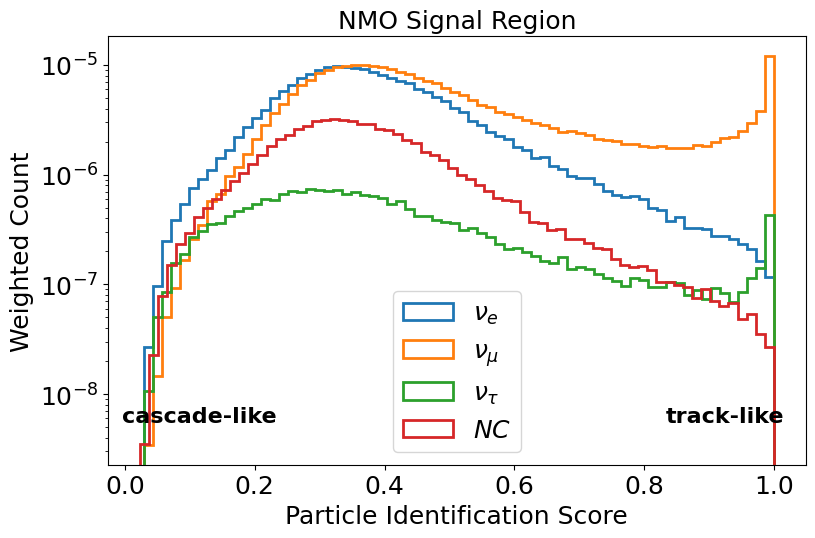

In [33]:
plt.hist(nue_cc_pid, weights=nue_cc_weights, histtype='step', bins=70, linewidth=2, label=r'$\nu_e$', log=True)
plt.hist(numu_cc_pid, weights=numu_cc_weights, histtype='step', bins=70, linewidth=2, label=r'$\nu_\mu$', log=True)
plt.hist(nutau_cc_pid, weights=nutau_cc_weights, histtype='step', bins=70, linewidth=2, label=r'$\nu_\tau$', log=True)
plt.hist(nc_pid, weights=nc_weights, histtype='step', bins=70, linewidth=2, label=r'$NC$', log=True)
#plt.axvline(x=0.6, c='k', linestyle='--')
plt.xlabel('Particle Identification Score')
plt.ylabel('Weighted Count')
plt.title('NMO Signal Region')
plt.text(0.02, 0.1, "cascade-like",
         transform=plt.gca().transAxes,
         fontsize=16,
         fontweight='bold')


plt.text(0.8, 0.1, "track-like",
         transform=plt.gca().transAxes,
         fontsize=16,
         fontweight='bold')


plt.legend()
plt.savefig('PID_weighted_count_signal_region.pdf', bbox_inches='tight', dpi=200)

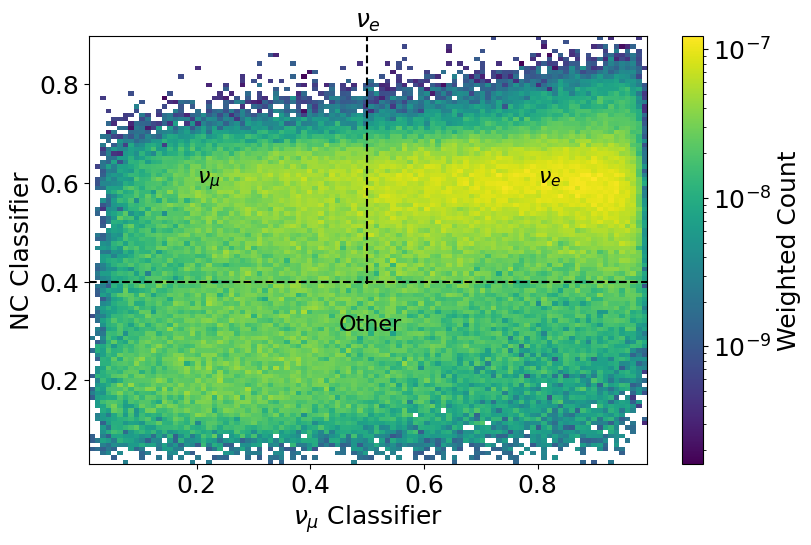

In [11]:
#plt.hist2d(nue_cc_numu[:][~np.isnan(nue_cc_numu[:])], nue_cc_nc[:][~np.isnan(nue_cc_nc[:])], bins=100, norm=LogNorm(), weights=(nue_cc_weights[:][~np.isnan(nue_cc_numu[:])], nue_cc_weights[:][~np.isnan(nue_cc_nc[:])]))
mask = (~np.isnan(nue_cc_numu)) & (~np.isnan(nue_cc_nc))
plt.hist2d(nue_cc_numu[mask], nue_cc_nc[mask], bins=100, norm=LogNorm(), weights=(nue_cc_weights[mask]))

plt.xlabel(r'$\nu_\mu$ Classifier')
plt.ylabel('NC Classifier')
plt.text(0.8, 0.6, r'$\nu_e$', c='k', fontsize=16)
plt.text(0.2, 0.6, r'$\nu_\mu$', c='k', fontsize=16)
plt.text(0.45, 0.3, 'Other', c='k', fontsize=16)
plt.axvline(x = 0.5, ymin = 0.42, c='k', linestyle='--')
plt.axhline(y = 0.4, c='k', linestyle='--')
plt.title(r'$\nu_e$')
cbar=plt.colorbar()
cbar.set_label('Weighted Count')
plt.savefig('NC_vs_NuMu_Classifier_NuE.pdf', bbox_inches='tight', dpi=200)

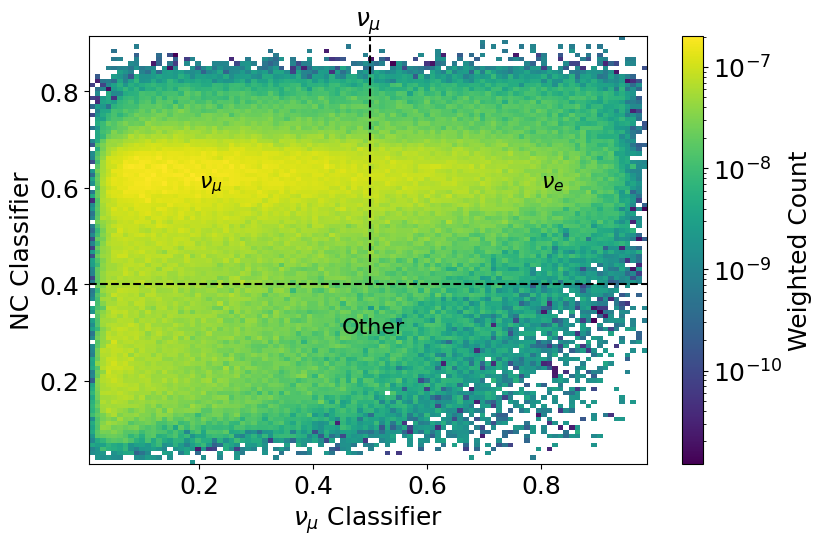

In [12]:
#plt.hist2d(numu_cc_numu[:][~np.isnan(numu_cc_numu[:])], numu_cc_nc[:][~np.isnan(numu_cc_nc[:])], bins=100, norm=LogNorm())
mask = (~np.isnan(numu_cc_numu)) & (~np.isnan(numu_cc_nc))
plt.hist2d(numu_cc_numu[mask], numu_cc_nc[mask], bins=100, norm=LogNorm(), weights=(numu_cc_weights[mask]))

plt.xlabel(r'$\nu_\mu$ Classifier')
plt.ylabel('NC Classifier')
plt.text(0.8, 0.6, r'$\nu_e$', c='k', fontsize=16)
plt.text(0.2, 0.6, r'$\nu_\mu$', c='k', fontsize=16)
plt.text(0.45, 0.3, 'Other', c='k', fontsize=16)
plt.axvline(x = 0.5, ymin = 0.42, c='k', linestyle='--')
plt.axhline(y = 0.4, c='k', linestyle='--')
plt.title(r'$\nu_\mu$')
cbar=plt.colorbar()
cbar.set_label('Weighted Count')
plt.savefig('NC_vs_NuMu_Classifier_NuMu.pdf', bbox_inches='tight', dpi=200)

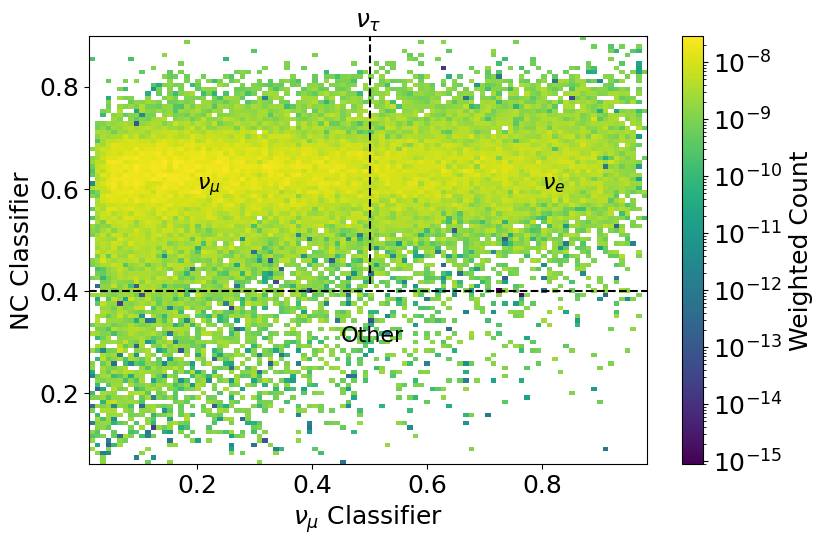

In [13]:
#plt.hist2d(nutau_cc_numu[:][~np.isnan(nutau_cc_numu[:])], nutau_cc_nc[:][~np.isnan(nutau_cc_nc[:])], bins=100, norm=LogNorm())
mask = (~np.isnan(nutau_cc_numu)) & (~np.isnan(nutau_cc_nc))
plt.hist2d(nutau_cc_numu[mask], nutau_cc_nc[mask], bins=100, norm=LogNorm(), weights=(nutau_cc_weights[mask]))

plt.xlabel(r'$\nu_\mu$ Classifier')
plt.ylabel('NC Classifier')
plt.text(0.8, 0.6, r'$\nu_e$', c='k', fontsize=16)
plt.text(0.2, 0.6, r'$\nu_\mu$', c='k', fontsize=16)
plt.text(0.45, 0.3, 'Other', c='k', fontsize=16)
plt.axvline(x = 0.5, ymin = 0.42, c='k', linestyle='--')
plt.axhline(y = 0.4, c='k', linestyle='--')
plt.title(r'$\nu_\tau$')
cbar=plt.colorbar()
cbar.set_label('Weighted Count')
plt.savefig('NC_vs_NuMu_Classifier_NuTau.pdf', bbox_inches='tight', dpi=200)

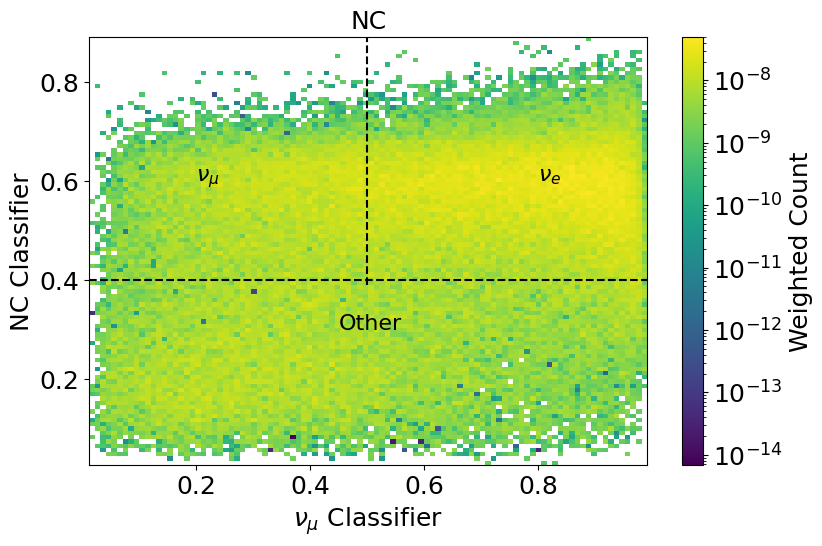

In [14]:
#plt.hist2d(nc_numu[:][~np.isnan(nc_numu[:])], nc_nc[:][~np.isnan(nc_nc[:])], bins=100, norm=LogNorm())

mask = (~np.isnan(nc_numu)) & (~np.isnan(nc_nc))
plt.hist2d(nc_numu[mask], nc_nc[mask], bins=100, norm=LogNorm(), weights=(nc_weights[mask]))

plt.xlabel(r'$\nu_\mu$ Classifier')
plt.ylabel('NC Classifier')
plt.text(0.8, 0.6, r'$\nu_e$', c='k', fontsize=16)
plt.text(0.2, 0.6, r'$\nu_\mu$', c='k', fontsize=16)
plt.text(0.45, 0.3, 'Other', c='k', fontsize=16)
plt.axvline(x = 0.5, ymin = 0.42, c='k', linestyle='--')
plt.axhline(y = 0.4, c='k', linestyle='--')
plt.title('NC')
cbar=plt.colorbar()
cbar.set_label('Weighted Count')
plt.savefig('NC_vs_NuMu_Classifier_NC.pdf', bbox_inches='tight', dpi=200)

In [ ]:
nue_cc_numu = np.hstack((df['nue_cc']['NuE_NuMu_BDT_classifier_score'][:], df['nuebar_cc']['NuE_NuMu_BDT_classifier_score'][:]))
nue_cc_nc = np.hstack((df['nue_cc']['NuE_NC_BDT_classifier_score'][:], df['nuebar_cc']['NuE_NC_BDT_classifier_score'][:]))
nue_cc_weights = np.hstack((df['nue_cc']['I3MCWeightDict.weight'][:], df['nuebar_cc']['I3MCWeightDict.weight'][:]))

numu_cc_numu = np.hstack((df['numu_cc']['NuE_NuMu_BDT_classifier_score'][:], df['numubar_cc']['NuE_NuMu_BDT_classifier_score'][:]))
numu_cc_nc = np.hstack((df['numu_cc']['NuE_NC_BDT_classifier_score'][:], df['numubar_cc']['NuE_NC_BDT_classifier_score'][:]))
numu_cc_weights = np.hstack((df['numu_cc']['I3MCWeightDict.weight'][:], df['numubar_cc']['I3MCWeightDict.weight'][:]))

nutau_cc_numu = np.hstack((df['nutau_cc']['NuE_NuMu_BDT_classifier_score'][:], df['nutaubar_cc']['NuE_NuMu_BDT_classifier_score'][:]))
nutau_cc_nc = np.hstack((df['nutau_cc']['NuE_NC_BDT_classifier_score'][:], df['nutaubar_cc']['NuE_NC_BDT_classifier_score'][:]))
nutau_cc_weights = np.hstack((df['nutau_cc']['I3MCWeightDict.weight'][:], df['nutaubar_cc']['I3MCWeightDict.weight'][:]))

nc_nc = np.hstack((df['nue_nc']['NuE_NC_BDT_classifier_score'][:], df['nuebar_nc']['NuE_NC_BDT_classifier_score'][:],
    df['numu_nc']['NuE_NC_BDT_classifier_score'][:], df['numubar_nc']['NuE_NC_BDT_classifier_score'][:],
    df['nutau_nc']['NuE_NC_BDT_classifier_score'][:], df['nutaubar_nc']['NuE_NC_BDT_classifier_score'][:]))

nc_numu = np.hstack((df['nue_nc']['NuE_NuMu_BDT_classifier_score'][:], df['nuebar_nc']['NuE_NuMu_BDT_classifier_score'][:],
    df['numu_nc']['NuE_NuMu_BDT_classifier_score'][:], df['numubar_nc']['NuE_NuMu_BDT_classifier_score'][:],
    df['nutau_nc']['NuE_NuMu_BDT_classifier_score'][:], df['nutaubar_nc']['NuE_NuMu_BDT_classifier_score'][:]))

nc_weights = np.hstack((df['nue_nc']['I3MCWeightDict.weight'][:], df['nuebar_nc']['I3MCWeightDict.weight'][:],
    df['numu_nc']['I3MCWeightDict.weight'][:], df['numubar_nc']['I3MCWeightDict.weight'][:],
    df['nutau_nc']['I3MCWeightDict.weight'][:], df['nutaubar_nc']['I3MCWeightDict.weight'][:]))